<a href="https://colab.research.google.com/github/naveenk08148-create/Netflix-Analysis/blob/main/Netflix_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
 # o6-oct(continued)

In [3]:
import matplotlib .pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv("netflix.csv")
df.head()
print(df.shape)

(8807, 12)


In [5]:
print(df.head)

<bound method NDFrame.head of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabal

In [6]:

df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
#Renaming the listed in column to genres
df.rename(columns={'listed_in':'genres'}, inplace=True)
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [8]:
if 'show_id' in df.columns:
  df.drop(columns='show_id',inplace=True)
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3
genres,0


In [10]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isna().sum()

np.int64(0)

In [11]:
df.dropna(subset=['rating'],inplace=True)
df['rating'].isna().sum()

np.int64(0)

In [12]:
df.dropna(subset=['duration'],inplace=True)
df['duration'].isna().sum()

np.int64(0)

In [13]:
df.isnull().sum()

,0
type,0
title,0
director,2621
cast,825
country,829
date_added,0
release_year,0
rating,0
duration,0
genres,0


In [14]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['date_added'].isnull().sum()


np.int64(88)

In [15]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isnull().sum()

np.int64(0)

In [16]:
df['day']=df['date_added'].dt.day
df['month']=df['date_added'].dt.month
df['year']=df['date_added'].dt.year
df['month_name']=df['date_added'].dt.month_name()
df['weekday']=df['date_added'].dt.day_name()
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [17]:
#07-oct

In [18]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [19]:
df['rating'] = df['rating'].replace(['TV-Y','TV-Y7','G','TV-G','PG','TV-PG','TV-Y7-FV'],'Kids')
df['rating'] = df['rating'].replace(['PG-13','TV-14'],'Teens')
df['rating'] = df['rating'].replace(['R','TV-MA','NC-17'],'Adults')
df['rating'] = df['rating'].replace(['NR','UR'],np.nan)
df.head()


,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [20]:
df['rating'].unique()

array(['Teens', 'Adults', 'Kids', nan], dtype=object)

In [21]:
df['rating'].isnull().sum()

np.int64(81)

In [22]:
df.dropna(subset=['rating'],inplace=True)
df['rating'].isnull().sum()

np.int64(0)

In [23]:
null = df.isna().sum()
null

,0
type,0
title,0
director,2535
cast,800
country,826
date_added,0
release_year,0
rating,0
duration,0
genres,0


In [24]:
df[(df['director'].isna())&(df['country'].isna())&(df['cast'].isna())].shape[0]


96

In [25]:
# how = all --- means only deletes rows where all null values are columns
df.dropna(subset= ['director','country','cast'], how ='all',inplace=True)
df.shape

(8525, 16)

In [26]:
null

,0
type,0
title,0
director,2535
cast,800
country,826
date_added,0
release_year,0
rating,0
duration,0
genres,0


In [27]:
df.isna().sum().sum()

np.int64(3873)

In [28]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday
5,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,Adults,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,24,9,2021,September,Friday


In [29]:
df['cast'][2]

'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera'

In [30]:
df_cast = pd.DataFrame(df['cast'].apply(lambda x: str(x).split(", ")).tolist(), index=df['title'])
df_cast

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
title,,,,,,,,,,,,,,,,,,,,,
Dick Johnson Is Dead,nan,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,None,None,None,None,None,None,None,None,None,None
Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,None,...,None,None,None,None,None,None,None,None,None,None
Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,None,...,None,None,None,None,None,None,None,None,None,None
Midnight Mass,Kate Siegel,Zach Gilford,Hamish Linklater,Henry Thomas,Kristin Lehman,Samantha Sloyan,Igby Rigney,Rahul Kohli,Annarah Cymone,Annabeth Gish,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinzana,Ali Suliman,Saleh Bakri,Yasa,Ali Al-Jabri,Mansoor Alfeeli,Ahd,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,None,None,None,None,None,None,None,None,None,None
Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [31]:
df_cast = df_cast.stack()
df_cast

title                  
Dick Johnson Is Dead  0                      nan
Blood & Water         0               Ama Qamata
                      1              Khosi Ngema
                      2            Gail Mabalane
                      3           Thabang Molaba
                                   ...          
Zubaan                3         Manish Chaudhary
                      4             Meghna Malik
                      5            Malkeet Rauni
                      6           Anita Shabdish
                      7    Chittaranjan Tripathy
Length: 63644, dtype: object

In [32]:
df_cast = pd.DataFrame(df_cast)
df_cast

0
title                                        
Dick Johnson Is Dead 0                    nan
Blood & Water        0             Ama Qamata
                     1            Khosi Ngema
                     2          Gail Mabalane
                     3         Thabang Molaba
...                                       ...
Zubaan               3       Manish Chaudhary
                     4           Meghna Malik
                     5          Malkeet Rauni
                     6         Anita Shabdish
                     7  Chittaranjan Tripathy

[63644 rows x 1 columns]

In [33]:
df_cast.reset_index(inplace=True)
df_cast

,title,level_1,0
0,Dick Johnson Is Dead,0,nan
1,Blood & Water,0,Ama Qamata
2,Blood & Water,1,Khosi Ngema
3,Blood & Water,2,Gail Mabalane
4,Blood & Water,3,Thabang Molaba
...,...,...,...
63639,Zubaan,3,Manish Chaudhary
63640,Zubaan,4,Meghna Malik
63641,Zubaan,5,Malkeet Rauni
63642,Zubaan,6,Anita Shabdish


In [34]:
df_cast = df_cast[['title', 0]]
df_cast

,title,0
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [35]:
df_cast.columns = ['title', 'cast']
df_cast

,title,cast
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [36]:
df_cast.replace('nan', np.nan, inplace=True)
df_cast.isna().sum()

/tmp/ipykernel_982/3418272751.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cast.replace('nan', np.nan, inplace=True)


,0
title,0
cast,704


In [37]:
df['country'][4]

'India'

In [38]:
df['country']

,country
0,United States
1,South Africa
2,NaN
4,India
5,NaN
...,...
8801,"United Arab Emirates, Jordan"
8802,United States
8804,United States
8805,United States


In [39]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description', 'day',
       'month', 'year', 'month_name', 'weekday'],
      dtype='object')

In [42]:
df_genre = pd.DataFrame(df['genres'].apply(lambda x: str(x).split(', ')).tolist(), index=df['title'])
df_genre = df_genre.stack()
df_genre = pd.DataFrame(df_genre)
df_genre.reset_index(inplace=True)
df_genre = df_genre[['title', 0]]
df_genre.columns = ['title', 'genres']
df_genre.replace('nan', np.nan, inplace=True)
df_genre.isna().sum()

,0
title,0
genres,0


In [43]:
df_director = pd.DataFrame(df['director'].apply(lambda x: str(x).split(', ')).tolist(), index=df['title'])
df_director = df_director.stack()
df_director = pd.DataFrame(df_director)
df_director.reset_index(inplace=True)
df_director = df_director[['title', 0]]
df_director.columns = ['title', 'director']
df_director.replace('nan', np.nan, inplace=True)
df_director.isna().sum()

,0
title,0
director,2439


In [44]:
df_country = pd.DataFrame(df['country'].apply(lambda x: str(x).split(', ')).tolist(), index=df['title'])
df_country = df_country.stack()
df_country = pd.DataFrame(df_country)
df_country.reset_index(inplace=True)
df_country = df_country[['title', 0]]
df_country.columns = ['title', 'country']
df_country.replace('nan', np.nan, inplace=True)
df_country.isna().sum()

,0
title,0
country,730


In [45]:
df12 = df_cast.merge(df_genre, on = 'title')
df12

,title,cast,genres
0,Dick Johnson Is Dead,NaN,Documentaries
1,Blood & Water,Ama Qamata,International TV Shows
2,Blood & Water,Ama Qamata,TV Dramas
3,Blood & Water,Ama Qamata,TV Mysteries
4,Blood & Water,Khosi Ngema,International TV Shows
...,...,...,...
146662,Zubaan,Anita Shabdish,International Movies
146663,Zubaan,Anita Shabdish,Music & Musicals
146664,Zubaan,Chittaranjan Tripathy,Dramas
146665,Zubaan,Chittaranjan Tripathy,International Movies


In [46]:
df123 = df_director.merge(df12, on= 'title')
df123

,title,director,cast,genres
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,NaN,Ama Qamata,International TV Shows
2,Blood & Water,NaN,Ama Qamata,TV Dramas
3,Blood & Water,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...
158309,Zubaan,Mozez Singh,Anita Shabdish,International Movies
158310,Zubaan,Mozez Singh,Anita Shabdish,Music & Musicals
158311,Zubaan,Mozez Singh,Chittaranjan Tripathy,Dramas
158312,Zubaan,Mozez Singh,Chittaranjan Tripathy,International Movies


In [47]:
df1234 = df_country.merge(df123, on = 'title')
df1234

,title,country,director,cast,genres
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [48]:
df_new = df.merge(df1234, on= 'title')
df_new

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genres_x,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genres_y
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [49]:
df_new = df.merge(df1234,on='title')
df_new

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genres_x,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genres_y
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [50]:
df_new.columns

Index(['type', 'title', 'director_x', 'cast_x', 'country_x', 'date_added',
       'release_year', 'rating', 'duration', 'genres_x', 'description', 'day',
       'month', 'year', 'month_name', 'weekday', 'country_y', 'director_y',
       'cast_y', 'genres_y'],
      dtype='object')

In [51]:
# df_new.drop(columns=['cast_x','country_x','director_x','genres_x'],inplace=True)
df_new.rename(columns={'country_y':'country','cast_y':'cast','director_y':'director','genres_y':'genre'},inplace=True)
df_new.head()

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genres_x,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows


In [52]:
df_new.shape

(198404, 20)

In [53]:
df_new.isna().sum()

,0
type,0
title,0
director_x,48645
cast_x,1882
country_x,11699
date_added,0
release_year,0
rating,0
duration,0
genres_x,0


In [54]:
df_new['cast']=df_new['cast'].replace(np.nan,'Unknown')
df_new['country']=df_new['country'].replace(np.nan,'Unknown')
df_new['director']=df_new['director'].replace(np.nan,'Unknown')


In [55]:
df_new.head()

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genres_x,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Khosi Ngema,International TV Shows


In [56]:
df_new.isna().sum()

,0
type,0
title,0
director_x,48645
cast_x,1882
country_x,11699
date_added,0
release_year,0
rating,0
duration,0
genres_x,0


In [57]:
df_new.duplicated().sum()

np.int64(55)

In [58]:
#in the new fataframe, we can see 55 rows which are duplicated

df_new.drop_duplicates(keep='first',inplace=True)


In [59]:
df_new.shape

(198349, 20)

In [60]:
#createing : 2 more dataframe for better analysiss by dividing the present data frame on the basis of type i.e movie and Tv
df_movies = df_new.loc[df_new['type']=='Movie']
df_tvs = df_new.loc[df_new['type']=='TV Show']

In [61]:
df_movies.shape

(144240, 20)

In [62]:
df_tvs.shape

(54109, 20)

In [63]:
df_movies["duration"].unique()

array(['90 min', '91 min', '125 min', '104 min', '127 min', '67 min',
       '94 min', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '110 min', '105 min', '96 min',
       '124 min', '116 min', '98 min', '23 min', '115 min', '122 min',
       '99 min', '88 min', '100 min', '102 min', '93 min', '95 min',
       '85 min', '83 min', '113 min', '13 min', '182 min', '48 min',
       '145 min', '87 min', '92 min', '80 min', '117 min', '128 min',
       '119 min', '143 min', '114 min', '118 min', '108 min', '63 min',
       '121 min', '142 min', '154 min', '120 min', '82 min', '109 min',
       '101 min', '86 min', '229 min', '76 min', '89 min', '156 min',
       '112 min', '107 min', '129 min', '135 min', '136 min', '165 min',
       '150 min', '133 min', '70 min', '84 min', '140 min', '78 min',
       '64 min', '59 min', '139 min', '69 min', '148 min', '189 min',
       '141 min', '130 min', '138 min', '81 min', '132 min', '123 min',
       '65

In [64]:
df_movies['duration']= df_movies['duration'].str.replace('min',"")
df_movies.head()

/tmp/ipykernel_982/840983273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['duration']= df_movies['duration'].str.replace('min',"")


,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genres_x,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
157,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,Kids,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,Unknown,Robert Cullen,Vanessa Hudgens,Children & Family Movies
158,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,Kids,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,Unknown,Robert Cullen,Kimiko Glenn,Children & Family Movies
159,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,Kids,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,Unknown,Robert Cullen,James Marsden,Children & Family Movies
160,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,Kids,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,Unknown,Robert Cullen,Sofia Carson,Children & Family Movies


In [65]:
df_movies.shape

(144240, 20)

In [66]:
df_tvs['duration']=df_tvs['duration'].str.replace('Seasons',"")
df_tvs['duration']=df_tvs['duration'].str.replace('Season',"")
df_tvs.head()

/tmp/ipykernel_982/61632933.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs['duration']=df_tvs['duration'].str.replace('Seasons',"")
/tmp/ipykernel_982/61632933.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs['duration']=df_tvs['duration'].str.replace('Season',"")


,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genres_x,description,day,month,year,month_name,weekday,country,director,cast,genre
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Khosi Ngema,International TV Shows
5,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Khosi Ngema,TV Dramas


In [67]:
df_tvs.rename(columns ={'duration':'seasons'},inplace=True)
df_tvs.head()

/tmp/ipykernel_982/2418892918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs.rename(columns ={'duration':'seasons'},inplace=True)


,type,title,director_x,cast_x,country_x,date_added,release_year,rating,seasons,genres_x,description,day,month,year,month_name,weekday,country,director,cast,genre
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Khosi Ngema,International TV Shows
5,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unknown,Khosi Ngema,TV Dramas


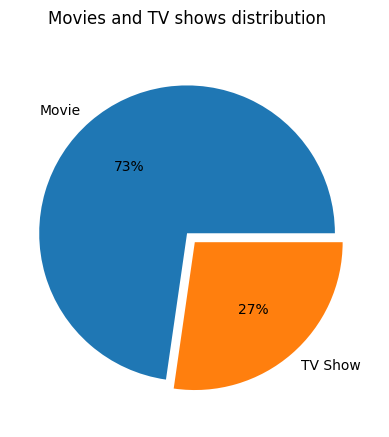

In [68]:
#Labels = ['Movie,'TV show ']
plt.pie(df_new['type'].value_counts(),labels = df_new['type'].value_counts().index,
        explode=(0.08,0),autopct='%0.0f%%')
plt.suptitle('Movies and TV shows distribution')
plt.show()

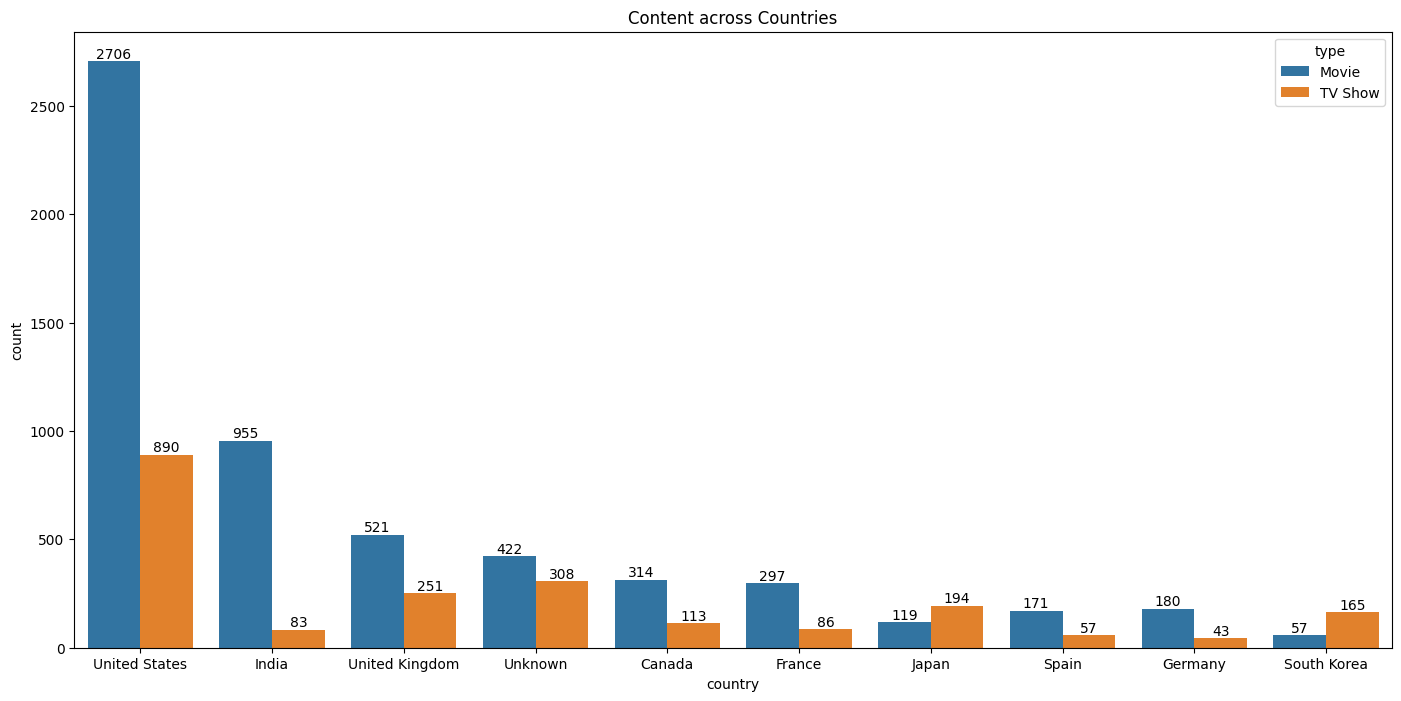

In [69]:
df_temp = df_new.drop_duplicates(subset=['country','title'])

x=df_temp['country'].value_counts().head(10)

plt.figure(figsize=(17,8))
plt.title('Content across Countries')
label = sns.countplot(data = df_temp, x = 'country',hue = 'type',order=x.index)
for i in label.containers:
  label.bar_label(i)
plt.show()

/tmp/ipykernel_982/2545539355.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_movies_temp, x = 'director',order=df_movies_temp['director'].value_counts()[1:11].index,palette="husl")
/tmp/ipykernel_982/2545539355.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='director',order=df_tvs_temp['director'].value_counts().index[1:11],palette='husl')


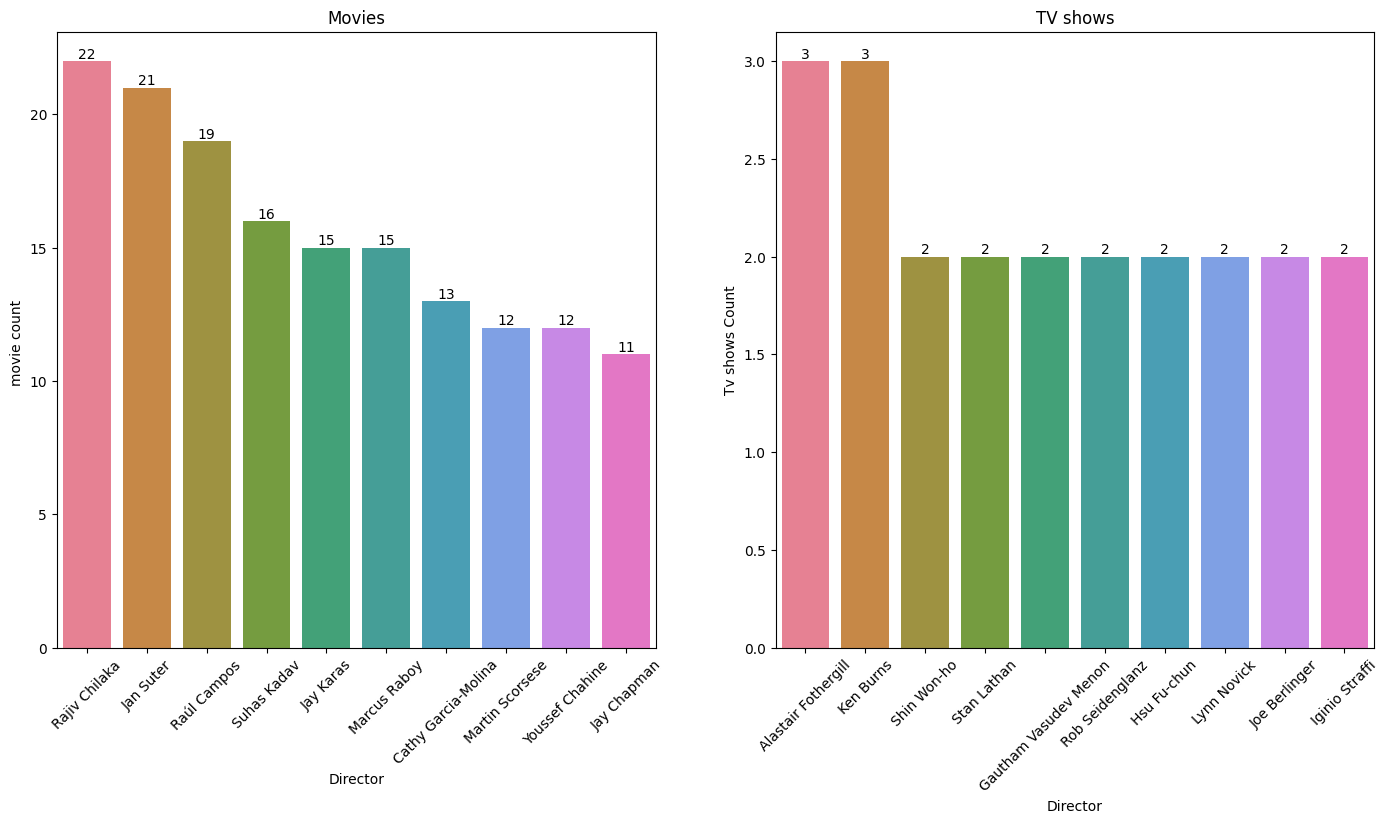

In [70]:
df_movies_temp = df_movies.drop_duplicates(subset = ['director','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['director','title'])

plt.figure(figsize=(17,8))
plt.subplot(1,2,1)
label = sns.countplot(data = df_movies_temp, x = 'director',order=df_movies_temp['director'].value_counts()[1:11].index,palette="husl")
for i in label.containers:
  label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel("Director")
plt.ylabel("movie count ")

plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp,x='director',order=df_tvs_temp['director'].value_counts().index[1:11],palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.title('TV shows')
plt.xticks(rotation=45)
plt.xlabel('Director')
plt.ylabel('Tv shows Count')
plt.show()


/tmp/ipykernel_982/1169270382.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_movies_temp, x = 'genre',order=df_movies_temp['genre'].value_counts()[1:11].index,palette="husl")
/tmp/ipykernel_982/1169270382.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='genre',order=df_tvs_temp['genre'].value_counts().index[1:11],palette='husl')


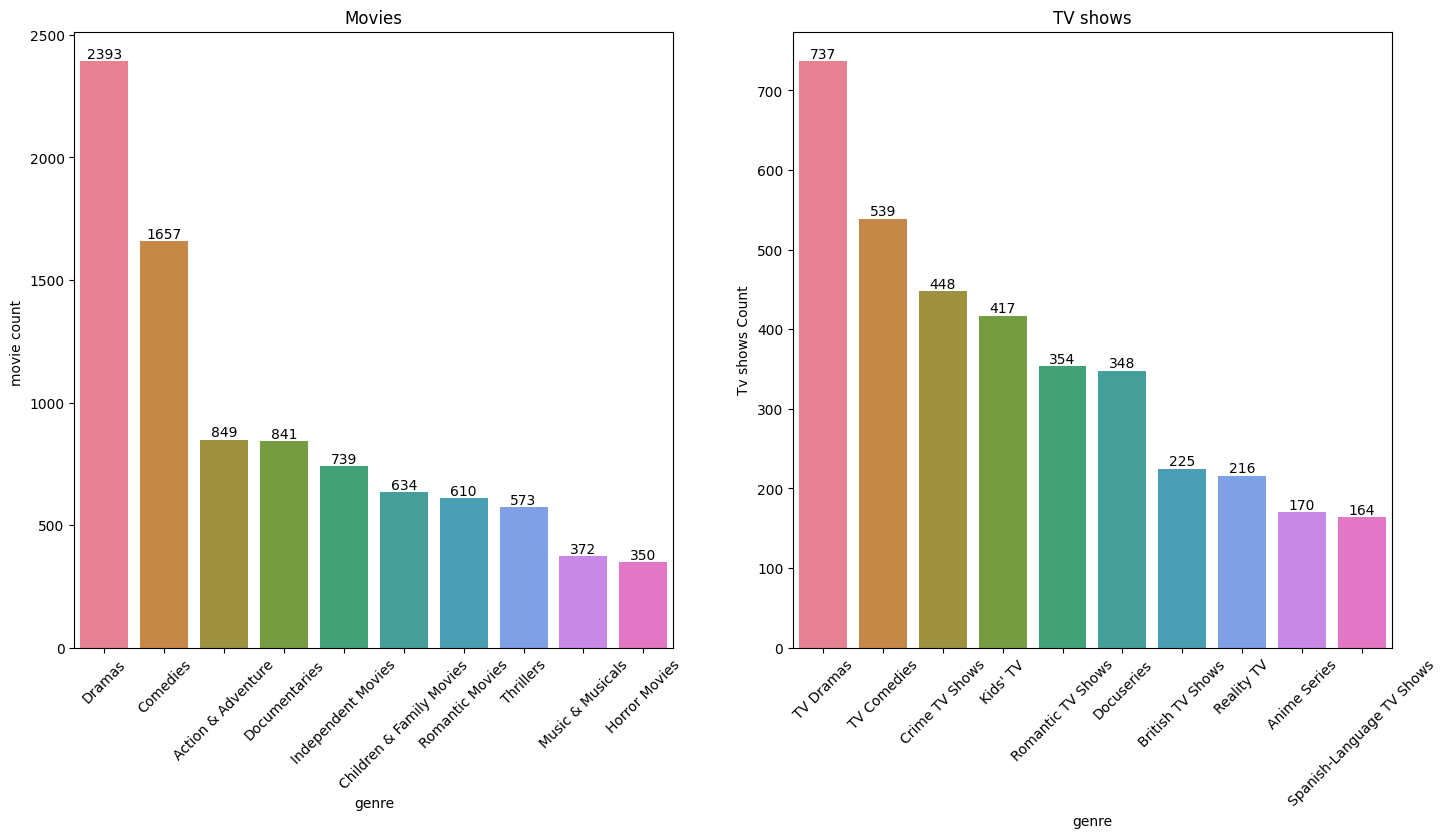

In [71]:
df_movies_temp = df_movies.drop_duplicates(subset = ['genre','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['genre','title'])

plt.figure(figsize=(17,8))
plt.subplot(1,2,1)
label = sns.countplot(data = df_movies_temp, x = 'genre',order=df_movies_temp['genre'].value_counts()[1:11].index,palette="husl")
for i in label.containers:
  label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel("genre")
plt.ylabel("movie count ")

plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp,x='genre',order=df_tvs_temp['genre'].value_counts().index[1:11],palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.title('TV shows')
plt.xticks(rotation=45)
plt.xlabel('genre')
plt.ylabel('Tv shows Count')
plt.show()


/tmp/ipykernel_982/1221648128.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_movies_temp, x = 'cast',order=df_movies_temp['cast'].value_counts()[1:11].index,palette="husl")
/tmp/ipykernel_982/1221648128.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='cast',order=df_tvs_temp['cast'].value_counts().index[1:11],palette='husl')


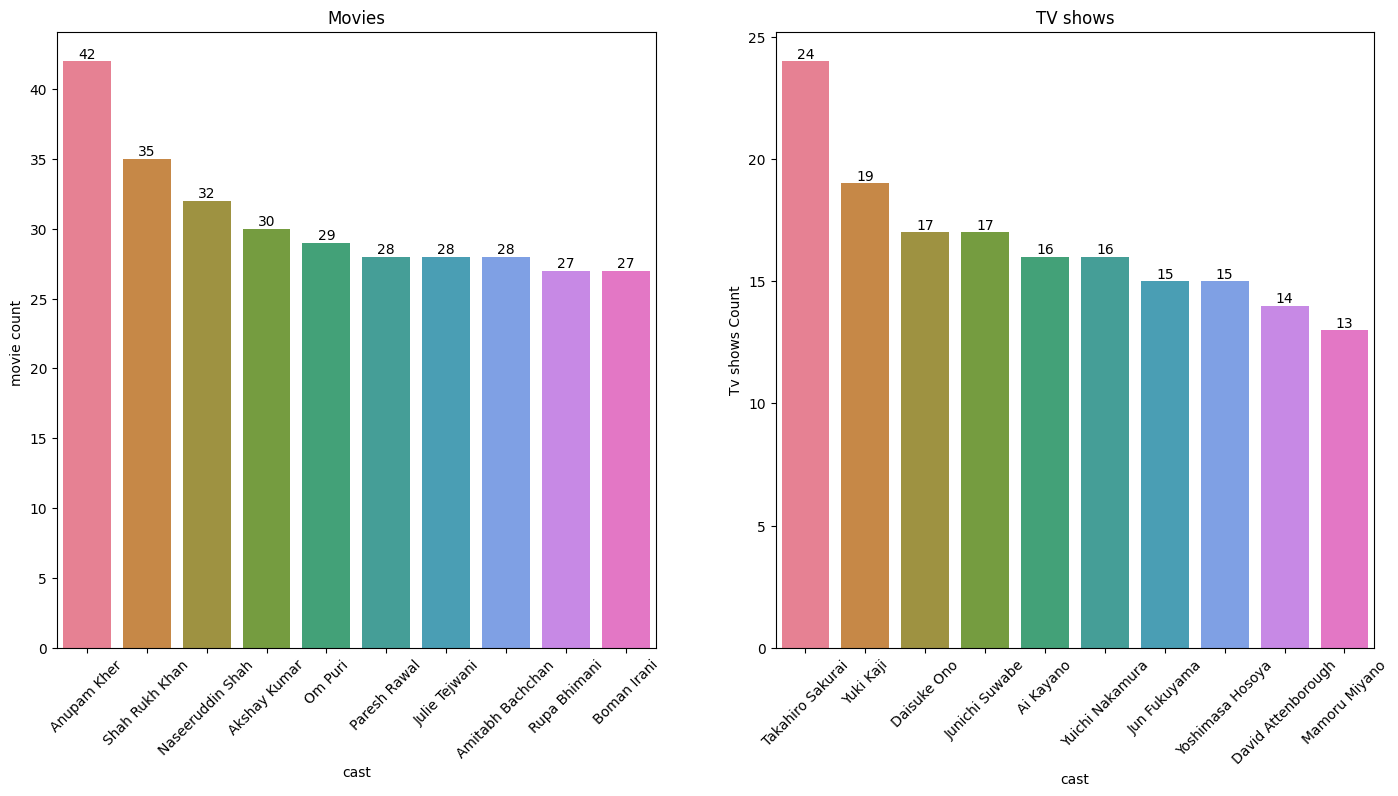

In [72]:
df_movies_temp = df_movies.drop_duplicates(subset = ['cast','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['cast','title'])

plt.figure(figsize=(17,8))
plt.subplot(1,2,1)
label = sns.countplot(data = df_movies_temp, x = 'cast',order=df_movies_temp['cast'].value_counts()[1:11].index,palette="husl")
for i in label.containers:
  label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel("cast")
plt.ylabel("movie count ")

plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp,x='cast',order=df_tvs_temp['cast'].value_counts().index[1:11],palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.title('TV shows')
plt.xticks(rotation=45)
plt.xlabel('cast')
plt.ylabel('Tv shows Count')
plt.show()

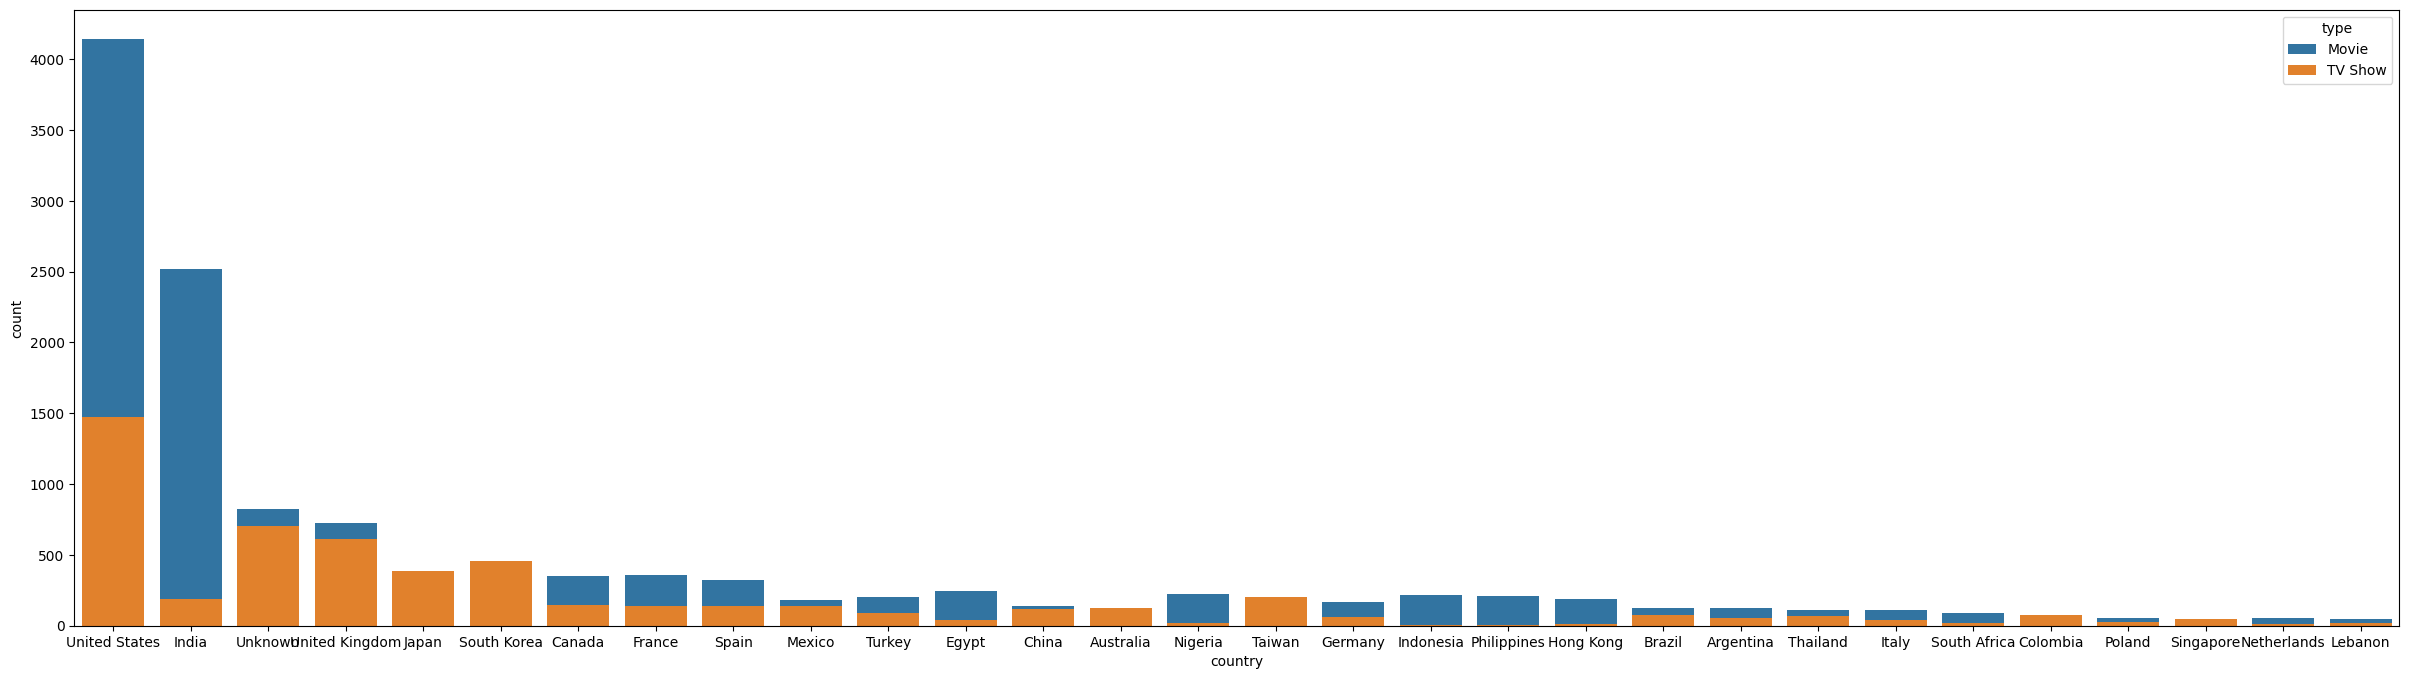

In [73]:
df_temp = df_new.drop_duplicates(subset=['genre','title'])
plt.figure(figsize=(30,8))
sns.countplot(data = df_temp,x ='country', hue = 'type', dodge = False,
              order = df_temp['country'].value_counts().head(30).index)
plt.show()

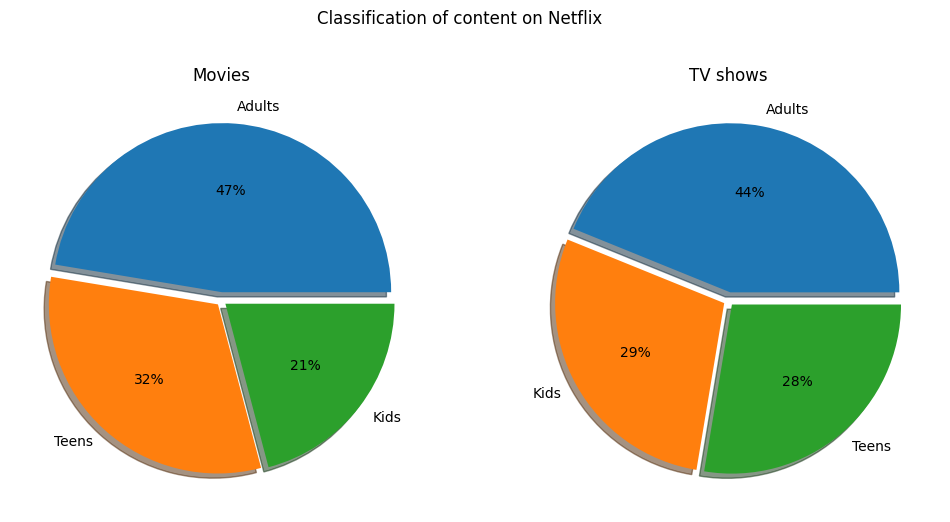

In [74]:
df_movies_temp = df_movies.drop_duplicates(subset = ['rating','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['rating','title'])

plt.figure(figsize=(12,6))
plt.suptitle('Classification of content on Netflix')

plt.subplot(1,2,1)
plt.pie(df_movies_temp['rating'].value_counts(),labels = df_movies_temp['rating'].value_counts().index,
        explode=(0.05,0.03,0.03),autopct='%.0f%%',shadow=True)
plt.title('Movies')

plt.subplot(1,2,2)
plt.pie(df_tvs_temp['rating'].value_counts(),labels = df_tvs_temp['rating'].value_counts().index,
        autopct='%0.0f%%',explode=(0.05,0.03,0.03),shadow=True)
plt.title('TV shows')
plt.show()

In [75]:
df_movies_temp = df_movies.drop_duplicates(subset=['year','title'])
df_movies


,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genres_x,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
157,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,Kids,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,Unknown,Robert Cullen,Vanessa Hudgens,Children & Family Movies
158,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,Kids,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,Unknown,Robert Cullen,Kimiko Glenn,Children & Family Movies
159,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,Kids,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,Unknown,Robert Cullen,James Marsden,Children & Family Movies
160,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,Kids,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,Unknown,Robert Cullen,Sofia Carson,Children & Family Movies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [76]:
mv_year = df_movies_temp['year'].value_counts()
mv_year

,count
year,
2019,1412
2020,1281
2018,1223
2021,986
2017,813
2016,224
2015,51
2014,19
2011,13


In [77]:
mv_year.sort_index(inplace=True)
mv_year

,count
year,
2008,1
2009,2
2011,13
2012,3
2013,3
2014,19
2015,51
2016,224
2017,813


In [78]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
mv_month = df_movies_temp['month_name'].value_counts().loc[month_order]
mv_month

,count
month_name,
January,535
February,375
March,518
April,542
May,433
June,485
July,559
August,515
September,510


In [79]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mv_day = df_movies_temp['weekday'].value_counts().loc[day_order]
mv_day

,count
weekday,
Monday,612
Tuesday,842
Wednesday,895
Thursday,1040
Friday,1537
Saturday,543
Sunday,562


/tmp/ipykernel_982/3294448600.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='year',order=mv_year.index,palette='husl')
/tmp/ipykernel_982/3294448600.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='month_name',order=mv_month.index,palette='husl')
/tmp/ipykernel_982/3294448600.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='weekday',order=mv_day.index,palette='husl')


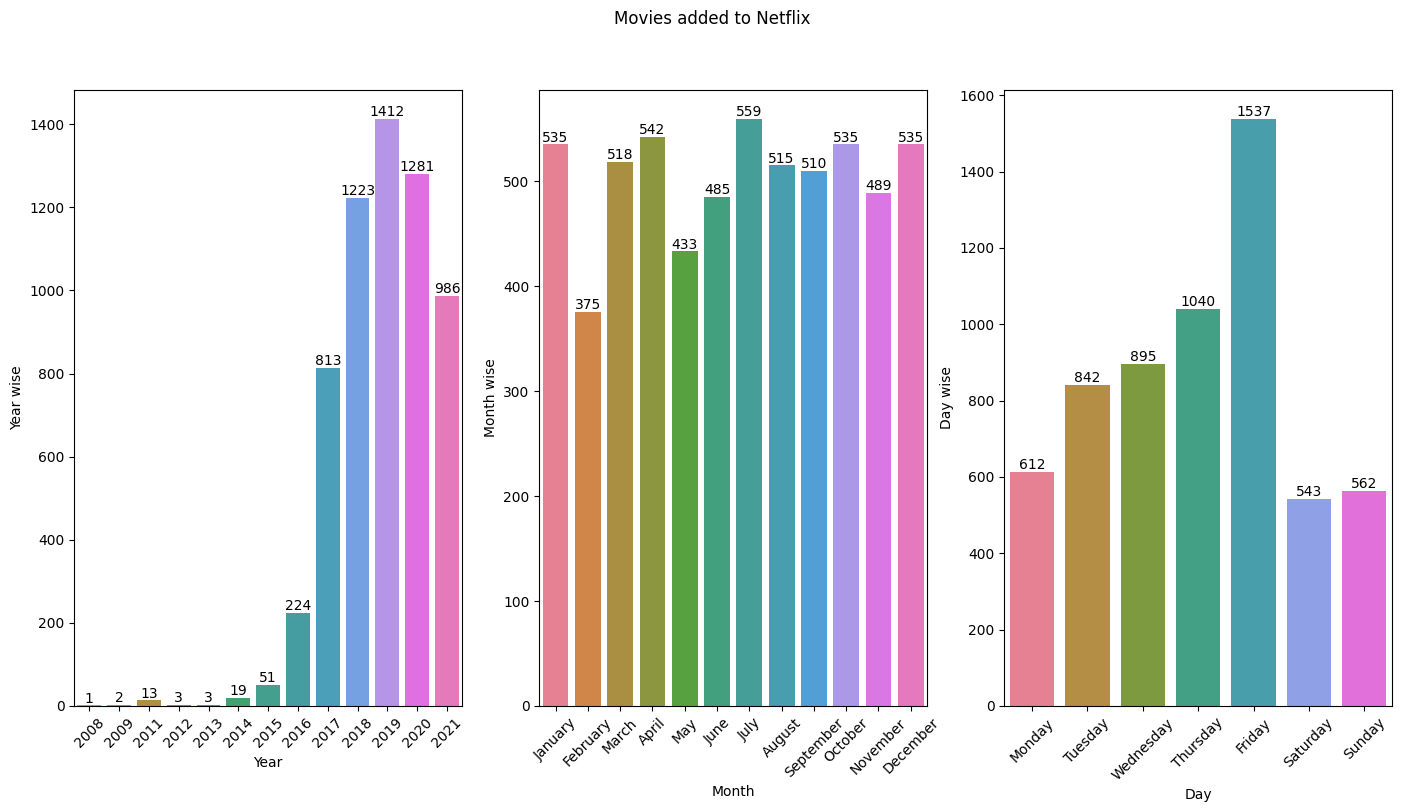

In [80]:
df_movies_temp=df_movies.drop_duplicates(subset=['year','title'])
df_movies_temp

mv_year=df_movies_temp['year'].value_counts()
mv_year.sort_index(inplace=True)

month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
mv_month=df_movies_temp['month_name'].value_counts().loc[month_order]

day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mv_day=df_movies_temp['weekday'].value_counts().loc[day_order]

plt.figure(figsize=(17,8))
plt.suptitle('Movies added to Netflix')

plt.subplot(1,3,1)
label=sns.countplot(data=df_movies_temp,x='year',order=mv_year.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('Year wise')

plt.subplot(1,3,2)
label=sns.countplot(data=df_movies_temp,x='month_name',order=mv_month.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Month wise')

plt.subplot(1,3,3)
label=sns.countplot(data=df_movies_temp,x='weekday',order=mv_day.index,palette='husl')
for i in label.containers:
  label.bar_label(i)
  plt.xticks(rotation=45)
  plt.xlabel('Day')
  plt.ylabel('Day wise')
plt.show()

/tmp/ipykernel_982/1259778448.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='year',order=tv_year.index.tolist(),palette='husl')
/tmp/ipykernel_982/1259778448.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='month_name',order=tv_month.index.tolist(),palette='husl')
/tmp/ipykernel_982/1259778448.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='weekday',order=tv_day.index.tolist(),palette='husl')


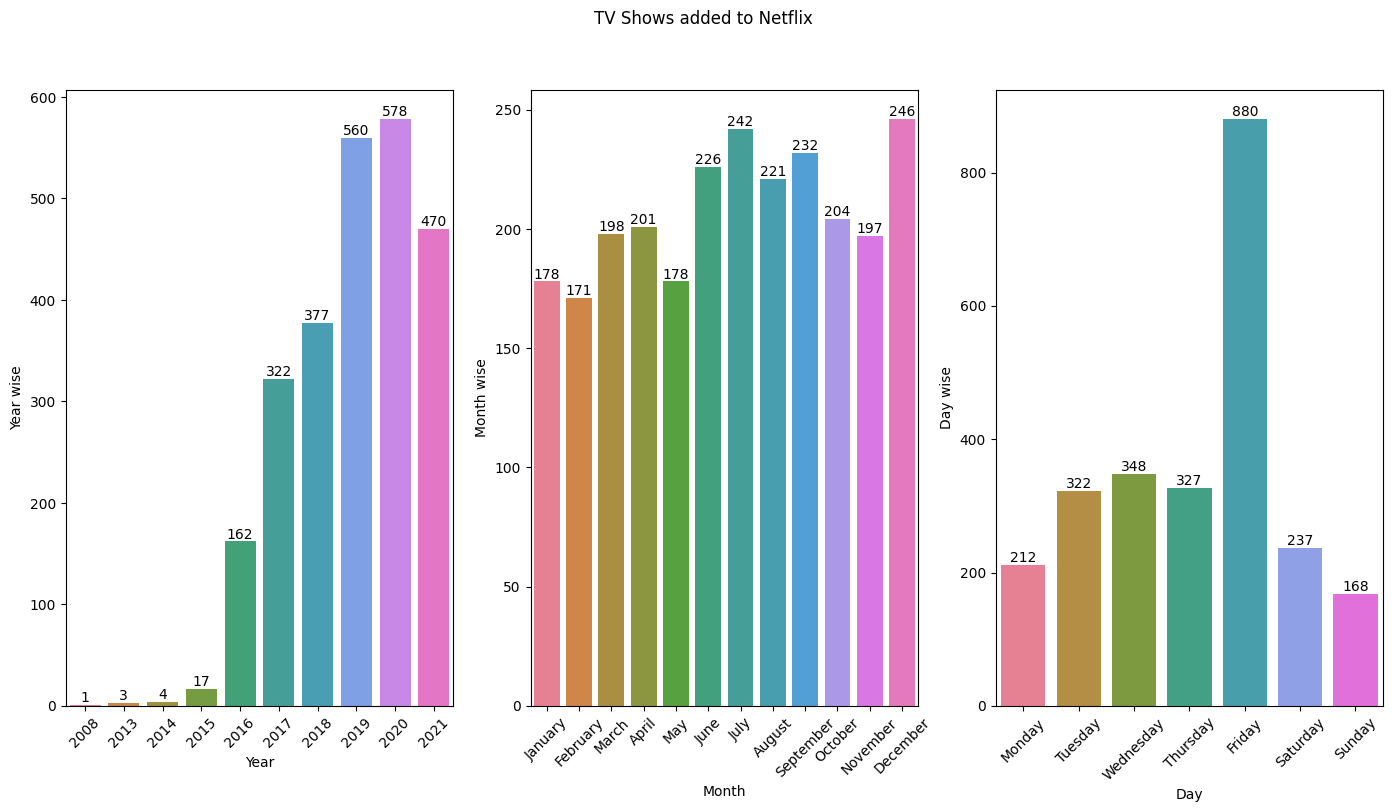

In [81]:
df_tvs_temp=df_tvs.drop_duplicates(subset=['year','title'])
df_tvs_temp

tv_year=df_tvs_temp['year'].value_counts()
tv_year.sort_index(inplace=True)

month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
tv_month=df_tvs_temp['month_name'].value_counts().loc[month_order]

day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
tv_day=df_tvs_temp['weekday'].value_counts().loc[day_order]

plt.figure(figsize=(17,8))
plt.suptitle('TV Shows added to Netflix')

plt.subplot(1,3,1)
label=sns.countplot(data=df_tvs_temp,x='year',order=tv_year.index.tolist(),palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('Year wise')

plt.subplot(1,3,2)
label=sns.countplot(data=df_tvs_temp,x='month_name',order=tv_month.index.tolist(),palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Month wise')

plt.subplot(1,3,3)
label=sns.countplot(data=df_tvs_temp,x='weekday',order=tv_day.index.tolist(),palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Day')
plt.ylabel('Day wise')
plt.show()

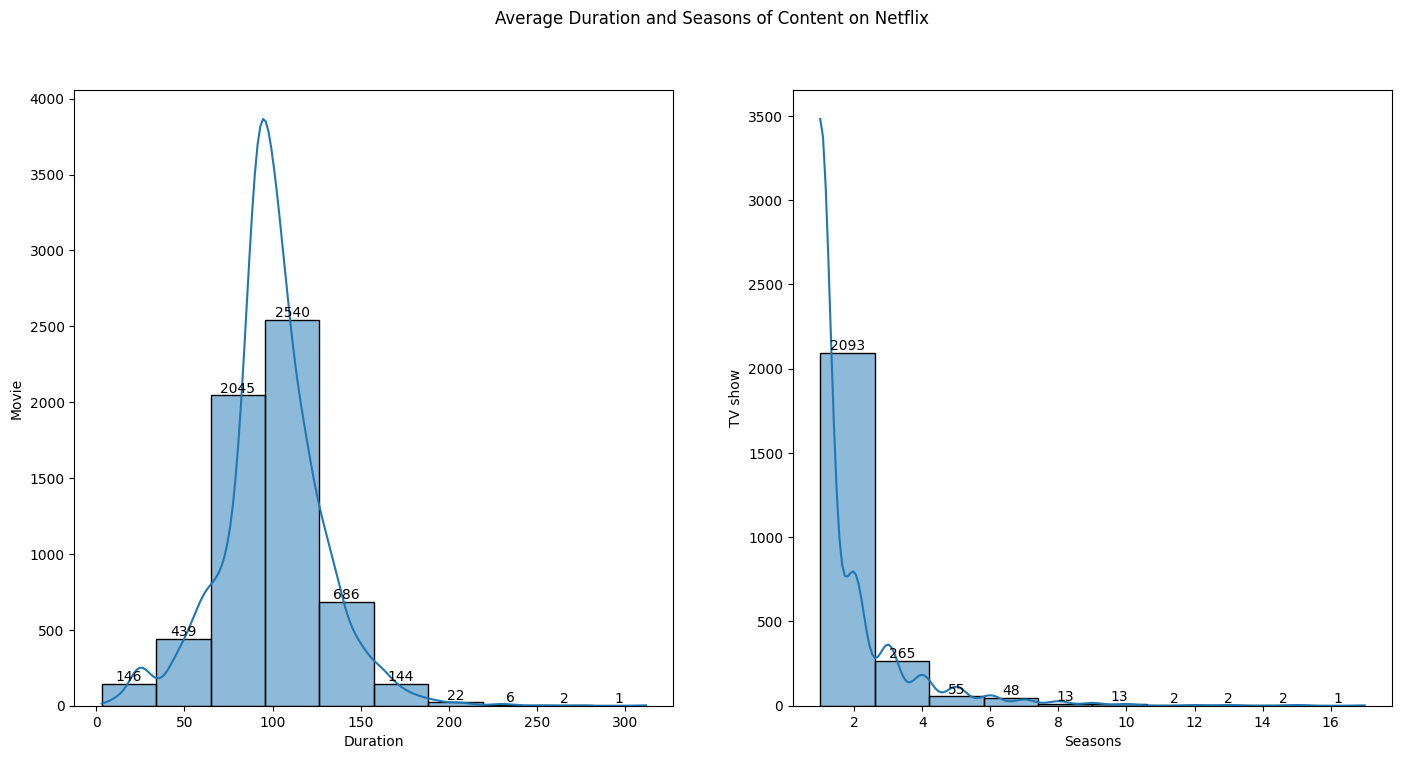

In [82]:
df_movies_temp = df_movies.drop_duplicates(subset=['duration','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset=['seasons','title'])

plt.figure(figsize=(17,8))
plt.suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)
label=sns.histplot(df_movies_temp['duration'].astype(int), bins=10,kde=True)
for i in label.containers:
  label.bar_label(i)
  plt.xlabel('Duration')
  plt.ylabel('Movie')

plt.subplot(1,2,2)
label=sns.histplot(df_tvs_temp['seasons'].astype(int), bins=10,kde=True)
for i in label.containers:
  label.bar_label(i)
plt.xlabel('Seasons')
plt.ylabel('TV show')
plt.show()



/tmp/ipykernel_982/3825342692.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies_temp['duration']= df_movies_temp['duration'].astype(int)
/tmp/ipykernel_982/3825342692.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs_temp['seasons']= df_tvs_temp['seasons'].astype(int)


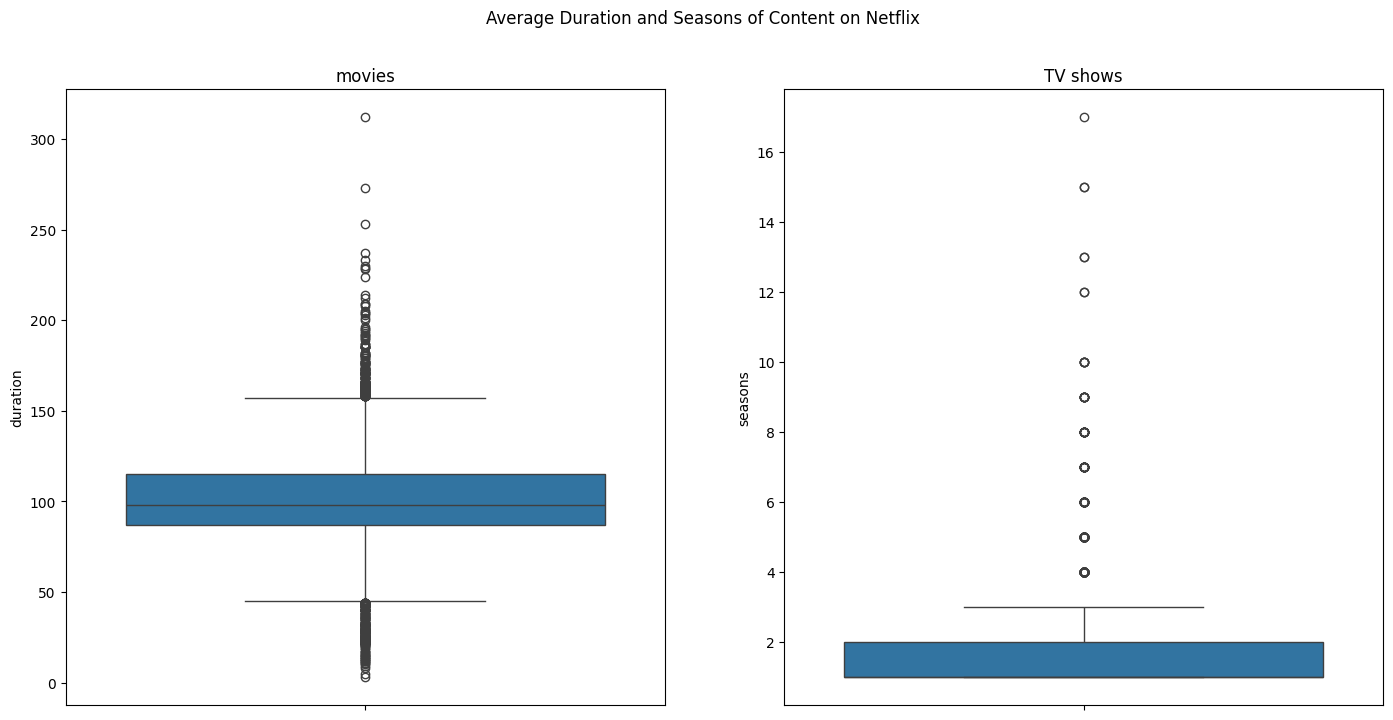

In [83]:
df_movies_temp = df_movies.drop_duplicates(subset=['duration','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset=['seasons','title'])

df_movies_temp['duration']= df_movies_temp['duration'].astype(int)
df_tvs_temp['seasons']= df_tvs_temp['seasons'].astype(int)

plt.figure(figsize=(17,8))
plt.suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)
sns.boxplot(y=df_movies_temp["duration"])
plt.title('movies')

plt.subplot(1,2,2)
sns.boxplot(y=df_tvs_temp['seasons'])
plt.title('TV shows')
plt.show()